# Задания 15 и 16. Рекуррентные нейронные сети

Что нужно сделать:
- **Часть 1** — временной ряд `births.csv` (ежедневное число родившихся девочек в Калифорнии в 1959 году):
  отложить последние 20% записей, визуализировать ряд двумя цветами, масштабировать данные в [0;1],
  скользящим окном сформировать X и Y (`y_len = 1`), собрать сеть из 1 рекуррентного и 1 линейного слоя,
  сравнить MAE и RMSE при разных `n_neurons_layer_h` и `x_len`, получить прогноз на отложенную выборку
  по принципу авторегрессии и сравнить его с истинными значениями;
- **Часть 2** — текст как временной ряд: буквы в one-hot представлении (словарь = 33 строчные русские буквы
  + пробел = 34 признака), та же сеть, но теперь это классификация следующей буквы из 34 классов
  (`CrossEntropyLoss`), авторегрессионная генерация продолжения и сравнение с истинными буквами.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import mean_absolute_error, mean_squared_error

torch.manual_seed(42)
np.random.seed(42)

## Часть 1. Временной ряд: число новорожденных девочек

В этой части у каждой записи ровно один признак (`n_feature = 1`) — количество новорожденных за день.
Сеть должна по `x_len` предыдущим дням предсказать следующий день (`y_len = 1`), то есть это регрессия.

### Шаг 1. Читаем данные и смотрим на них

In [2]:
df = pd.read_csv("births.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


In [3]:
df.info()
print()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    365 non-null    datetime64[us]
 1   Births  365 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 5.8 KB

Date      0
Births    0
dtype: int64


In [4]:
df["Births"].describe()

count    365.000000
mean      41.980822
std        7.348257
min       23.000000
25%       37.000000
50%       42.000000
75%       46.000000
max       73.000000
Name: Births, dtype: float64

В наборе 365 записей — по одной на каждый день 1959 года, пропусков нет. Число рождений колеблется
от 23 до 73 при среднем около 42.

### Шаг 2. Откладываем последние 20% записей и рисуем ряд

In [5]:
series = df["Births"].values.astype(np.float32)
dates = df["Date"].values

n_train = int(len(series) * 0.8)      # первые 80% - обучающая часть
train = series[:n_train]
test = series[n_train:]

print("всего записей:", len(series))
print("обучающая часть:", len(train), " отложенная часть:", len(test))

всего записей: 365
обучающая часть: 292  отложенная часть: 73


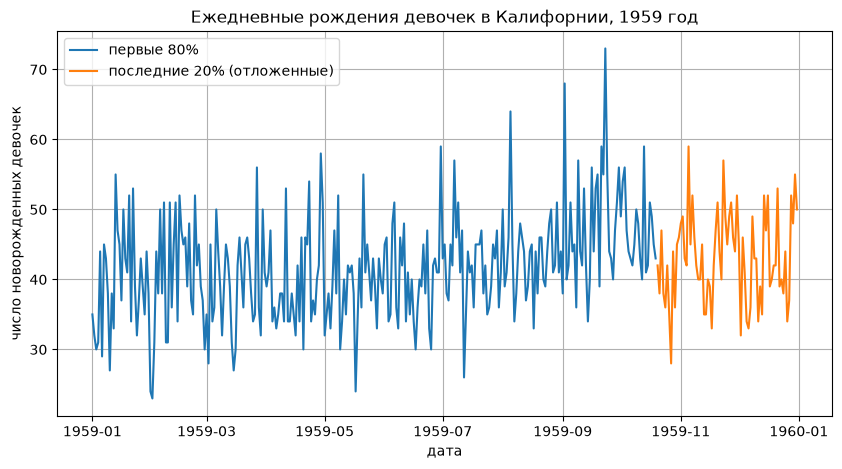

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(dates[:n_train], train, label="первые 80%")
plt.plot(dates[n_train:], test, label="последние 20% (отложенные)")
plt.xlabel("дата")
plt.ylabel("число новорожденных девочек")
plt.title("Ежедневные рождения девочек в Калифорнии, 1959 год")
plt.legend()
plt.grid(True)
plt.show()

Ряд очень шумный: значения скачут день ото дня почти на 20-30 единиц. Заметен только слабый рост уровня
к середине года, а выраженной сезонности или периодичности, за которую могла бы зацепиться сеть, здесь нет.

### Шаг 3. Масштабируем данные в диапазон [0;1]

Рекуррентному слою удобнее работать с небольшими значениями, поэтому приводим ряд к [0;1]:
$x_{scaled} = (x - min) / (max - min)$. Минимум и максимум считаем **только по обучающим 80%** —
иначе информация об отложенной выборке протечет в обучение.

In [7]:
x_min = train.min()
x_max = train.max()

train_s = (train - x_min) / (x_max - x_min)
test_s = (test - x_min) / (x_max - x_min)

print("min и max по обучающей части:", x_min, x_max)
print("обучающая после масштабирования: от", train_s.min(), "до", train_s.max())
print("отложенная после масштабирования: от", round(float(test_s.min()), 3), "до", round(float(test_s.max()), 3))

min и max по обучающей части: 23.0 73.0
обучающая после масштабирования: от 0.0 до 1.0
отложенная после масштабирования: от 0.1 до 0.72


### Шаг 4. Формируем X и Y скользящим окном

Идем окном по ряду: `x_len` подряд идущих записей — это один обучающий пример X, а следующая запись — ответ Y.
Форма X для рекуррентного слоя — (число примеров, длина последовательности, число признаков).

In [8]:
def make_xy(data, x_len, y_len=1):
    X = []
    Y = []
    for i in range(len(data) - x_len - y_len + 1):
        X.append(data[i:i + x_len])
        Y.append(data[i + x_len:i + x_len + y_len])
    X = np.array(X, dtype=np.float32).reshape(-1, x_len, 1)
    Y = np.array(Y, dtype=np.float32)
    return torch.tensor(X), torch.tensor(Y)

In [9]:
# посмотрим, что получается при x_len = 5
X, Y = make_xy(train_s, x_len=5)
print("X:", X.shape, " Y:", Y.shape)
print("первый пример X:", X[0].numpy().ravel())
print("ответ Y:", Y[0].numpy())

X: torch.Size([287, 5, 1])  Y: torch.Size([287, 1])
первый пример X: [0.24 0.18 0.14 0.16 0.42]
ответ Y: [0.12]


### Шаг 5. Модель: 1 рекуррентный слой + 1 линейный слой

`nn.RNN` возвращает выходы для всех шагов последовательности, нам нужен только последний — по нему
линейный слой выдает одно число (прогноз следующей записи). Функция потерь — MSE, оптимизатор — Adam.

In [10]:
class RNNRegressor(nn.Module):
    def __init__(self, n_neurons_layer_h):
        super().__init__()
        self.rnn = nn.RNN(1, n_neurons_layer_h, batch_first=True)
        self.fc = nn.Linear(n_neurons_layer_h, 1)

    def forward(self, x):
        out, h = self.rnn(x)
        return self.fc(out[:, -1, :])   # берем выход последнего шага

In [11]:
def train_model(X, Y, n_neurons_layer_h, epochs=200):
    model = RNNRegressor(n_neurons_layer_h)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    losses = []
    for epoch in range(epochs):
        order = torch.randperm(len(X))
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, len(X), 32):
            batch = order[i:i + 32]
            optimizer.zero_grad()
            loss = loss_fn(model(X[batch]), Y[batch])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)

    return model, losses

Два способа получить прогноз на отложенную выборку:

- **на 1 шаг вперёд** — каждое окно берется из истинных значений ряда, сеть предсказывает только следующий день;
- **авторегрессия** — стартуем с последних `x_len` истинных обучающих записей, предсказанное значение
  дописываем в окно и предсказываем по нему следующее, и так до конца отложенной выборки. Истинные значения
  отложенной выборки при этом не используются вообще.

In [12]:
def predict_onestep(model, data_s, x_len, n_steps):
    # окна из истинных значений: прогноз каждый раз только на 1 день вперёд
    X, Y = make_xy(data_s[-(n_steps + x_len):], x_len)
    with torch.no_grad():
        pred_s = model(X).numpy().ravel()
    return pred_s * (x_max - x_min) + x_min   # обратно в исходный масштаб


def predict_autoreg(model, train_s, x_len, n_steps):
    window = list(train_s[-x_len:])   # последние известные записи обучающей части
    pred_s = []
    for step in range(n_steps):
        x = np.array(window[-x_len:], dtype=np.float32).reshape(1, x_len, 1)
        with torch.no_grad():
            next_value = model(torch.tensor(x)).item()
        pred_s.append(next_value)
        window.append(next_value)     # свой же прогноз становится входом
    return np.array(pred_s) * (x_max - x_min) + x_min

### Шаг 6. Сравниваем работу сети при разных `n_neurons_layer_h` и `x_len`

In [13]:
full_s = np.concatenate([train_s, test_s])   # понадобится для прогноза на 1 шаг вперёд

results = []
models = {}

for n_neurons_layer_h in [8, 16, 32]:
    for x_len in [5, 10, 20]:
        X, Y = make_xy(train_s, x_len)
        model, losses = train_model(X, Y, n_neurons_layer_h)

        pred_one = predict_onestep(model, full_s, x_len, len(test))
        pred_auto = predict_autoreg(model, train_s, x_len, len(test))

        results.append({
            "n_neurons_layer_h": n_neurons_layer_h,
            "x_len": x_len,
            "MSE обучение": round(losses[-1], 5),
            "MAE (1 шаг)": round(mean_absolute_error(test, pred_one), 3),
            "RMSE (1 шаг)": round(np.sqrt(mean_squared_error(test, pred_one)), 3),
            "MAE (авторегрессия)": round(mean_absolute_error(test, pred_auto), 3),
            "RMSE (авторегрессия)": round(np.sqrt(mean_squared_error(test, pred_auto)), 3),
        })
        models[(n_neurons_layer_h, x_len)] = (model, losses)

results = pd.DataFrame(results)
results

,n_neurons_layer_h,x_len,MSE обучение,MAE (1 шаг),RMSE (1 шаг),MAE (авторегрессия),RMSE (авторегрессия)
0,8,5,0.02143,5.058,6.357,5.501,6.797
1,8,10,0.02061,5.247,6.562,6.025,7.488
2,8,20,0.01719,6.683,7.927,7.857,9.564
3,16,5,0.02131,5.076,6.228,5.275,6.450
4,16,10,0.01944,5.627,6.901,5.519,6.869
5,16,20,0.01835,5.952,7.105,7.470,9.180
6,32,5,0.02163,5.111,6.342,5.384,6.639
7,32,10,0.02010,6.036,7.305,6.151,7.465
8,32,20,0.02010,5.487,6.784,5.573,6.835


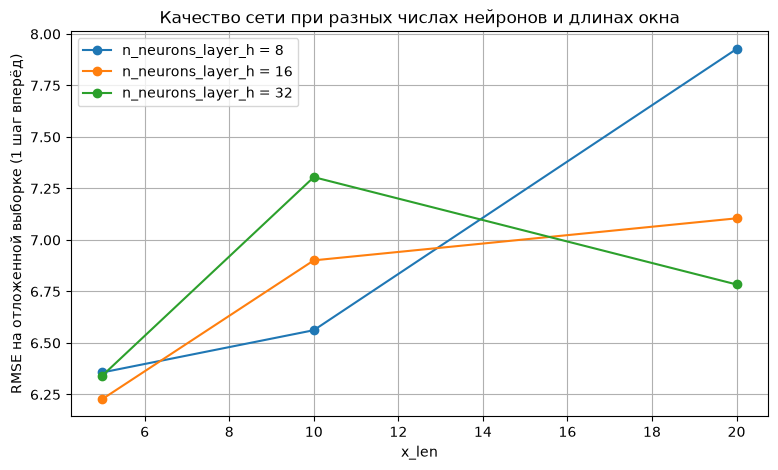

In [14]:
plt.figure(figsize=(9, 5))
for n_neurons_layer_h in [8, 16, 32]:
    part = results[results["n_neurons_layer_h"] == n_neurons_layer_h]
    plt.plot(part["x_len"], part["RMSE (1 шаг)"], marker="o", label="n_neurons_layer_h = %d" % n_neurons_layer_h)

plt.xlabel("x_len")
plt.ylabel("RMSE на отложенной выборке (1 шаг вперёд)")
plt.title("Качество сети при разных числах нейронов и длинах окна")
plt.legend()
plt.grid(True)
plt.show()

Все конфигурации дают примерно одинаковое качество: MAE от 5.1 до 6.7, RMSE от 6.2 до 7.9. Лучший результат
у сети с `n_neurons_layer_h = 16` и `x_len = 5` (MAE 5.08, RMSE 6.23), и дальше работаем именно с ней.

Видно две вещи. Во-первых, число нейронов в рекуррентном слое почти ничего не меняет: 8, 16 и 32 нейрона дают
разницу в пределах десятых. Во-вторых, увеличение `x_len` качество скорее ухудшает — при `x_len = 20` RMSE
на 1 шаг вперёд поднимается до 6.8-7.9, а по авторегрессии до 9.6. Это логично: в ряде нет длинной
закономерности, и длинное окно подает на вход больше шума, а обучающих примеров при этом становится меньше.

### Шаг 7. Кривая ошибки лучшей модели

лучшая модель: n_neurons_layer_h = 16 , x_len = 5


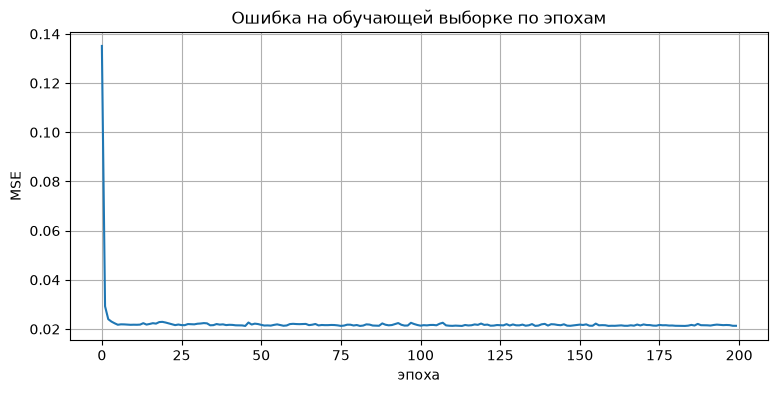

In [15]:
best = results.sort_values("RMSE (1 шаг)").iloc[0]
best_neurons = int(best["n_neurons_layer_h"])
best_x_len = int(best["x_len"])
print("лучшая модель: n_neurons_layer_h =", best_neurons, ", x_len =", best_x_len)

model, losses = models[(best_neurons, best_x_len)]

plt.figure(figsize=(9, 4))
plt.plot(losses)
plt.xlabel("эпоха")
plt.ylabel("MSE")
plt.title("Ошибка на обучающей выборке по эпохам")
plt.grid(True)
plt.show()

Ошибка быстро падает за первые десятки эпох и дальше держится на одном уровне — сеть уже забрала из ряда
все, что могла, а остаток MSE — это шум, который в принципе не предсказуем.

### Шаг 8. Прогноз на отложенную выборку по принципу авторегрессии

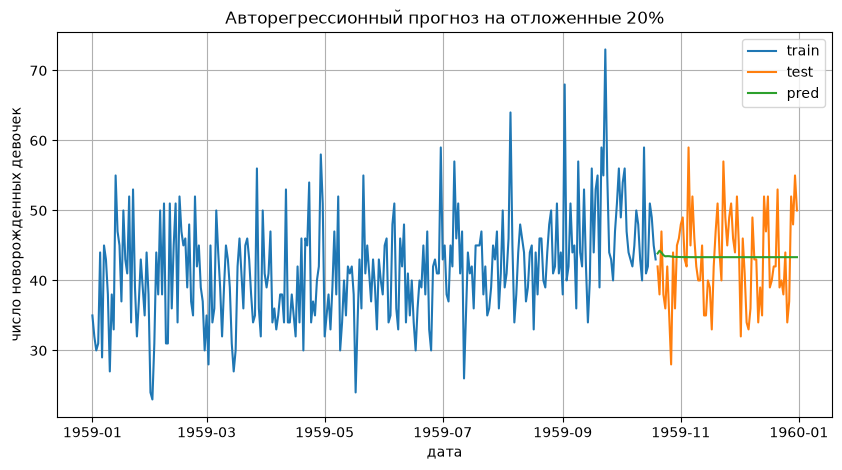

In [16]:
pred_auto = predict_autoreg(model, train_s, best_x_len, len(test))

plt.figure(figsize=(10, 5))
plt.plot(dates[:n_train], train, label="train")
plt.plot(dates[n_train:], test, label="test")
plt.plot(dates[n_train:], pred_auto, label="pred")
plt.xlabel("дата")
plt.ylabel("число новорожденных девочек")
plt.title("Авторегрессионный прогноз на отложенные 20%")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# для сравнения: прогноз на 1 шаг вперёд и совсем наивный прогноз "всегда среднее по обучающей части"
pred_one = predict_onestep(model, full_s, best_x_len, len(test))
pred_mean = np.full(len(test), train.mean())

pd.DataFrame({
    "MAE": [mean_absolute_error(test, pred_auto),
            mean_absolute_error(test, pred_one),
            mean_absolute_error(test, pred_mean)],
    "RMSE": [np.sqrt(mean_squared_error(test, pred_auto)),
             np.sqrt(mean_squared_error(test, pred_one)),
             np.sqrt(mean_squared_error(test, pred_mean))],
}, index=["авторегрессия", "прогноз на 1 шаг вперёд", "среднее по обучающей части"]).round(3)

,MAE,RMSE
авторегрессия,5.275,6.450
прогноз на 1 шаг вперёд,5.076,6.228
среднее по обучающей части,5.304,6.555


In [18]:
print("первые 10 значений прогноза:", pred_auto[:10].round(2))
print("последние 5 значений прогноза:", pred_auto[-5:].round(2))
print("разброс прогноза (std):", round(float(pred_auto.std()), 3),
      " разброс истинных значений (std):", round(float(test.std()), 3))

первые 10 значений прогноза: [43.85 44.25 43.98 43.61 43.45 43.47 43.47 43.42 43.38 43.36]
последние 5 значений прогноза: [43.32 43.32 43.32 43.32 43.32]
разброс прогноза (std): 0.147  разброс истинных значений (std): 6.423


Прогноз почти сразу вырождается: первые 2-3 значения еще как-то шевелятся (43.9, 44.2, 44.0), а дальше
кривая становится почти прямой на уровне 43.3. Разброс прогноза std = 0.15 против std = 6.4 у истинных
значений — сеть просто предсказывает средний уровень ряда.

Так и должно быть при авторегрессии на много шагов вперёд: свой собственный прогноз подается на вход, и уже
через `x_len` шагов в окне не остается ни одного настоящего значения — сеть смотрит только на свои же
сглаженные ответы, шум из них исчез, и прогноз сходится к неподвижной точке. Метрики это подтверждают:
авторегрессия (MAE 5.28, RMSE 6.45) практически не отличается от наивного "всегда предсказываем среднее
по обучающей части" (MAE 5.30, RMSE 6.56). Для этого конкретного ряда это не столько беда сети, сколько
свойство данных — ежедневное число рождений почти случайно, предсказывать в нем нечего.

## Часть 2. Текст как временной ряд

Последовательность букв — тоже временной ряд: номер записи — это позиция буквы в тексте, а данные в записи —
сама буква. Отличие от части 1 в том, что буква — не непрерывное число, а один из элементов словаря,
поэтому представляем ее в виде one-hot вектора и решаем задачу классификации следующей буквы.

### Шаг 1. Словарь и one-hot представление буквы

In [19]:
alphabet = list("абвгдеёжзийклмнопрстуфхцчшщъыьэюя") + [" "]
char2idx = {c: i for i, c in enumerate(alphabet)}

n_dict = len(alphabet)
print("длина словаря (число признаков у буквы):", n_dict)
print(alphabet)

длина словаря (число признаков у буквы): 34
['а', 'б', 'в', 'г', 'д', 'е', 'ё', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ъ', 'ы', 'ь', 'э', 'ю', 'я', ' ']


In [20]:
def to_onehot(codes):
    # каждая буква -> вектор длины 34 с единицей на своем месте
    return np.eye(n_dict, dtype=np.float32)[codes]


print("буква 'а':", to_onehot(np.array([char2idx["а"]]))[0].astype(int))
print("буква 'б':", to_onehot(np.array([char2idx["б"]]))[0].astype(int))
print("пробел   :", to_onehot(np.array([char2idx[" "]]))[0].astype(int))

буква 'а': [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
буква 'б': [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
пробел   : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


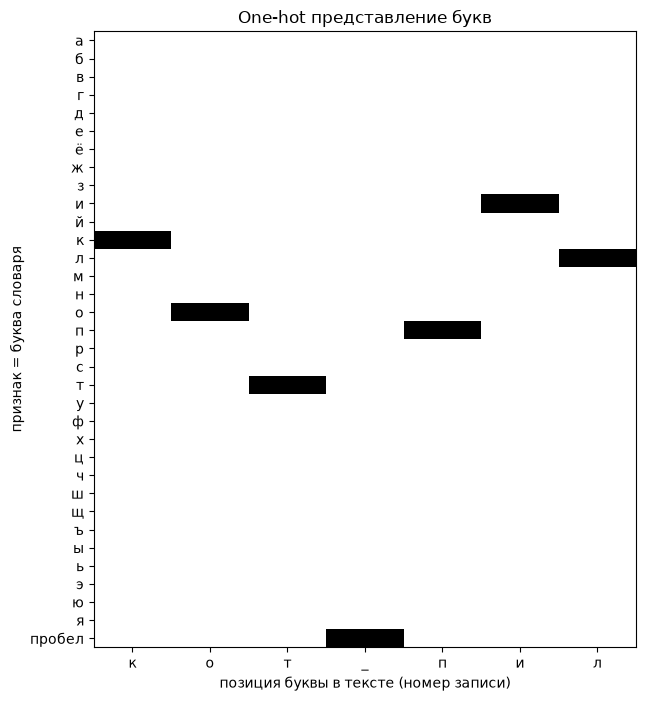

In [21]:
word = "кот пил"
codes_word = np.array([char2idx[c] for c in word])

plt.figure(figsize=(7, 8))
plt.imshow(to_onehot(codes_word).T, aspect="auto", cmap="Greys")
plt.xticks(range(len(word)), [c if c != " " else "_" for c in word])
plt.yticks(range(n_dict), alphabet[:-1] + ["пробел"])
plt.xlabel("позиция буквы в тексте (номер записи)")
plt.ylabel("признак = буква словаря")
plt.title("One-hot представление букв")
plt.show()

У каждой буквы 34 признака, и ровно один из них равен единице — это и есть номер буквы в словаре.

### Шаг 2. Готовим тексты

In [22]:
text1 = "кот пил молоко и пес пил молоко " * 40
text2 = "сегодня был дождь и завтра будет дождь " * 40

print("длина текста 1:", len(text1))
print(text1[:80])
print()
print("длина текста 2:", len(text2))
print(text2[:80])

длина текста 1: 1280
кот пил молоко и пес пил молоко кот пил молоко и пес пил молоко кот пил молоко и

длина текста 2: 1560
сегодня был дождь и завтра будет дождь сегодня был дождь и завтра будет дождь се


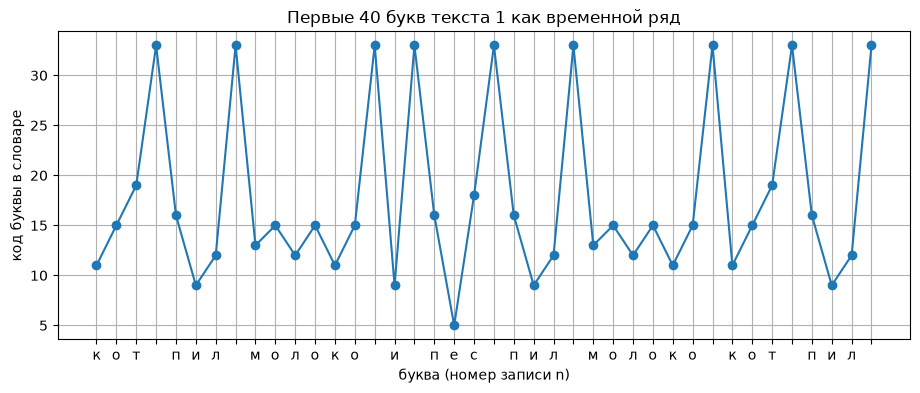

In [23]:
# тот же текст как временной ряд: по оси X - номер записи, по оси Y - код буквы
codes1 = np.array([char2idx[c] for c in text1])

plt.figure(figsize=(11, 4))
plt.plot(codes1[:40], marker="o")
plt.xticks(range(40), list(text1[:40]))
plt.xlabel("буква (номер записи n)")
plt.ylabel("код буквы в словаре")
plt.title("Первые 40 букв текста 1 как временной ряд")
plt.grid(True)
plt.show()

### Шаг 3. Формируем X и Y по 80% записей

Окно то же, что в части 1: `x_len` подряд идущих букв в one-hot — это X, следующая буква — ответ Y.
Только Y теперь не число, а номер класса (от 0 до 33), поэтому его тип — `long`.

In [24]:
def make_xy_text(codes, x_len):
    X = []
    Y = []
    for i in range(len(codes) - x_len):
        X.append(to_onehot(codes[i:i + x_len]))
        Y.append(codes[i + x_len])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y), dtype=torch.long)

In [25]:
x_len = 15

n_train_text = int(len(codes1) * 0.8)
train_codes1 = codes1[:n_train_text]
test_codes1 = codes1[n_train_text:]

X1, Y1 = make_xy_text(train_codes1, x_len)
print("обучающих букв:", len(train_codes1), " отложенных букв:", len(test_codes1))
print("X:", X1.shape, " Y:", Y1.shape)

обучающих букв: 1024  отложенных букв: 256
X: torch.Size([1009, 15, 34])  Y: torch.Size([1009])


### Шаг 4. Модель: 1 рекуррентный слой + 1 линейный слой, но теперь классификация

Отличия от части 1: на входе рекуррентного слоя 34 признака вместо одного, на выходе линейного слоя —
34 числа (оценки принадлежности каждому классу-букве), функция потерь — `CrossEntropyLoss` вместо MSE.

In [26]:
class RNNTextClassifier(nn.Module):
    def __init__(self, n_neurons_layer_h):
        super().__init__()
        self.rnn = nn.RNN(n_dict, n_neurons_layer_h, batch_first=True)
        self.fc = nn.Linear(n_neurons_layer_h, n_dict)

    def forward(self, x):
        out, h = self.rnn(x)
        return self.fc(out[:, -1, :])

In [27]:
def train_text_model(X, Y, n_neurons_layer_h=32, epochs=150):
    model = RNNTextClassifier(n_neurons_layer_h)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    losses = []
    for epoch in range(epochs):
        order = torch.randperm(len(X))
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, len(X), 32):
            batch = order[i:i + 32]
            optimizer.zero_grad()
            loss = loss_fn(model(X[batch]), Y[batch])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)

    return model, losses


def generate_autoreg(model, train_codes, x_len, n_steps):
    # авторегрессия: предсказанную букву дописываем в окно и предсказываем следующую
    window = list(train_codes[-x_len:])
    pred_codes = []
    for step in range(n_steps):
        x = to_onehot(np.array(window[-x_len:]))
        with torch.no_grad():
            next_code = model(torch.tensor(x).unsqueeze(0)).argmax(dim=1).item()
        pred_codes.append(next_code)
        window.append(next_code)
    return np.array(pred_codes)

### Шаг 5. Обучаем сеть на тексте 1 и генерируем продолжение

CrossEntropyLoss на последней эпохе: 7e-05


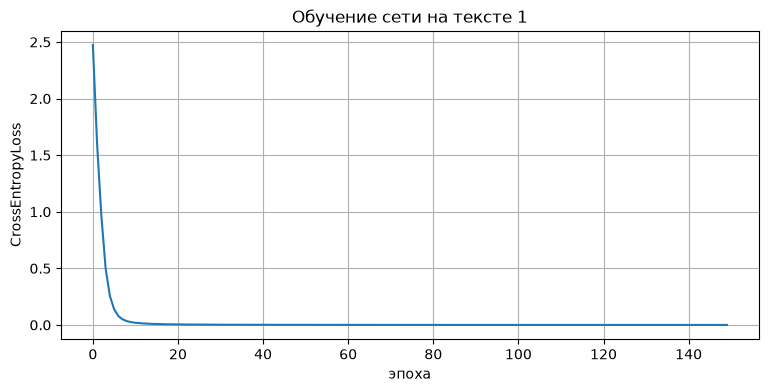

In [28]:
model1, losses1 = train_text_model(X1, Y1)
print("CrossEntropyLoss на последней эпохе:", round(losses1[-1], 5))

plt.figure(figsize=(9, 4))
plt.plot(losses1)
plt.xlabel("эпоха")
plt.ylabel("CrossEntropyLoss")
plt.title("Обучение сети на тексте 1")
plt.grid(True)
plt.show()

In [29]:
pred_codes1 = generate_autoreg(model1, train_codes1, x_len, len(test_codes1))

true_str1 = "".join(alphabet[i] for i in test_codes1)
pred_str1 = "".join(alphabet[i] for i in pred_codes1)

print("истина :", true_str1[:100])
print("прогноз:", pred_str1[:100])
print()
print("доля совпавших букв:", round(float(np.mean(pred_codes1 == test_codes1)), 4))

истина : кот пил молоко и пес пил молоко кот пил молоко и пес пил молоко кот пил молоко и пес пил молоко кот 
прогноз: кот пил молоко и пес пил молоко кот пил молоко и пес пил молоко кот пил молоко и пес пил молоко кот 

доля совпавших букв: 1.0


### Шаг 6. То же самое для текста 2

In [30]:
codes2 = np.array([char2idx[c] for c in text2])

n_train_text2 = int(len(codes2) * 0.8)
train_codes2 = codes2[:n_train_text2]
test_codes2 = codes2[n_train_text2:]

X2, Y2 = make_xy_text(train_codes2, x_len)
model2, losses2 = train_text_model(X2, Y2)
print("CrossEntropyLoss на последней эпохе:", round(losses2[-1], 5))

CrossEntropyLoss на последней эпохе: 4e-05


In [31]:
pred_codes2 = generate_autoreg(model2, train_codes2, x_len, len(test_codes2))

true_str2 = "".join(alphabet[i] for i in test_codes2)
pred_str2 = "".join(alphabet[i] for i in pred_codes2)

print("истина :", true_str2[:100])
print("прогноз:", pred_str2[:100])
print()
print("доля совпавших букв:", round(float(np.mean(pred_codes2 == test_codes2)), 4))

истина : сегодня был дождь и завтра будет дождь сегодня был дождь и завтра будет дождь сегодня был дождь и за
прогноз: сегодня был дождь и завтра будет дождь сегодня был дождь и завтра будет дождь сегодня был дождь и за

доля совпавших букв: 1.0


На обоих текстах авторегрессия сработала идеально: доля совпавших букв = 1.0, сгенерированное продолжение
буква в букву совпало с истинным. Разница с частью 1 огромная, и причина в данных: фраза строго зацикленная,
никакого шума в ней нет, поэтому по 15 предыдущим буквам следующая определяется однозначно, и ошибка не
накапливается — сеть каждый раз подает себе на вход правильную букву.

### Шаг 7. Как на текст влияет длина окна `x_len`

В тексте 1 фрагмент "пил молоко " встречается дважды — после "кот" и после "пес". Если окно короткое,
сеть просто не видит, кто пил, и не может угадать, что идет дальше. Проверим это.

In [32]:
rows = []
for x_len_try in [5, 10, 15]:
    for name, codes in [("текст 1", codes1), ("текст 2", codes2)]:
        n_tr = int(len(codes) * 0.8)
        X, Y = make_xy_text(codes[:n_tr], x_len_try)
        m, ls = train_text_model(X, Y)
        pred = generate_autoreg(m, codes[:n_tr], x_len_try, len(codes) - n_tr)
        rows.append({
            "текст": name,
            "x_len": x_len_try,
            "CrossEntropyLoss": round(ls[-1], 5),
            "доля совпавших букв": round(float(np.mean(pred == codes[n_tr:])), 4),
        })

pd.DataFrame(rows)

,текст,x_len,CrossEntropyLoss,доля совпавших букв
0,текст 1,5,0.04682,0.1406
1,текст 2,5,0.03890,0.1859
2,текст 1,10,0.04776,0.0859
3,текст 2,10,0.00004,1.0000
4,текст 1,15,0.00006,1.0000
5,текст 2,15,0.00004,1.0000


Короткое окно ломает прогноз: при `x_len = 5` обе сети угадывают лишь 14-19% букв, при `x_len = 10`
текст 2 уже воспроизводится идеально, а текст 1 проседает до 9%. Причина видна по самим фразам: чтобы понять,
что идет после "молоко ", нужно помнить, кто пил — а слово "кот"/"пес" стоит примерно на 13 букв раньше.
Окна из 5 и 10 букв до него не достают, и сеть выбирает одно из двух продолжений наугад: буквы получаются
осмысленные, но фаза цикла сбивается, и посимвольное совпадение падает. Ошибка потерь у таких сетей тоже
не опускается ниже ~0.04 — это как раз цена неопределенности в точке ветвления.

## Общий вывод

Одна и та же архитектура (1 рекуррентный слой + 1 линейный слой) решила обе задачи, но задачи по сути разные:

- в части 1 у записи 1 непрерывный признак, сеть предсказывает число — это **регрессия**, функция потерь MSE,
  метрики MAE и RMSE;
- в части 2 у записи 34 признака (one-hot буквы), сеть выдает 34 числа — оценки принадлежности к каждому
  классу-букве, то есть это **классификация**, функция потерь CrossEntropyLoss, метрика — доля совпавших букв.

Авторегрессия в обоих случаях работает одинаково (свой прогноз дописывается во входное окно), а вот результат
получается прямо противоположный. На шумном ряде рождений прогноз через несколько шагов вырождается в среднее
значение, потому что предсказывать там почти нечего и накопленная ошибка все стирает. На зацикленной фразе,
где следующая буква однозначно определяется предыдущими, авторегрессия воспроизводит текст без ошибок сколь
угодно долго. И там же видно главное ограничение: окно `x_len` должно быть достаточно длинным, чтобы в него
попадала та часть последовательности, которая действительно определяет ответ.